# 📋 Practice 3. Propagation of State and Covariance

## ■ 시스템 모델 (Process Equation)

- x_{k+1} = F · x_k + G · u_k + w_k
- w_k ~ N(0, Q)

```
F = [ 0.2   0.4 ]      G = [ 0 ]      Q = diag(1, 2)
    [-0.4   1.0 ]          [ 1 ]
```

## ■ 조건

- 초기 평균: x̄_0 = [10, 20]ᵀ
- 초기 공분산: P_0 = diag(40, 40)
- 제어 입력: u_k = 1
- 시뮬레이션 구간: k = 0 ~ 14

## ■ 핵심 공식 (책 식 4.2, 4.4)

평균 전파:
```
x̄_{k+1} = F · x̄_k + G · u_k
```

공분산 전파:
```
P_{k+1} = F · P_k · Fᵀ + Q
```

---

## ■ 풀이 절차

### 1️⃣ 초기 조건 설정
- 시스템 행렬 F, G, Q 정의
- 초기 평균 x̄_0, 초기 공분산 P_0 설정

### 2️⃣ 저장 배열 준비
- 각 시간 step의 평균과 공분산 대각 원소를 저장할 배열 생성

### 3️⃣ 시간 루프 (Propagation)
- 평균: x̄_{k+1} = F · x̄_k + G · u_k
- 공분산: P_{k+1} = F · P_k · Fᵀ + Q
- 매 step마다 결과 저장

### 4️⃣ 결과 시각화
- 위 그래프: prey, predator의 평균 (population mean)
- 아래 그래프: prey, predator의 분산 (population variance, P의 대각 원소)

### 5️⃣ Steady-state 검증
- 이론값: x̄_ss = (I - F)⁻¹ · G · u = [2.5, 5]ᵀ
- P_ss ≈ [[2.88, 3.08], [3.08, 7.96]]

---

## ■ 한줄 정리

> 👉 "측정 없이, 시스템 모델만으로 상태의 평균과 공분산이 시간에 따라 어떻게 퍼지는지 전파하는 과정 (= 칼만필터의 Prediction step)"

---

## 💡 헷갈리기 쉬운 포인트

- `@` vs `*` : `@`는 행렬곱, `*`는 element-wise 곱. 행렬 연산은 반드시 `@` 사용
- `F.T` : F의 전치(transpose). `np.transpose(F)`와 동일
- `np.diag(행렬)` : 행렬 → 대각 원소 1D 배열
- `np.diag(1D배열)` : 1D 배열 → 대각행렬 (반대 방향)
- `np.linalg.solve(A, b)` : Ax = b 풀이. `np.linalg.inv(A) @ b`보다 빠르고 안정적


In [10]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import numpy as np
import matplotlib.pyplot as plt


# =========================================
# 2️⃣ 시스템 모델 정의
#    x_{k+1} = F @ x_k + G * u_k + w_k
#    w_k ~ N(0, Q)
# =========================================
F = np.array([[0.2, 0.4],
              [-0.4, 1.0]])              # (2,2) 상태 전이 행렬

G = np.array([[0.0],
              [1.0]])                    # (2,1) 입력 행렬 (열벡터로 명시)

Q = np.diag([1.0, 2.0])                  # (2,2) process noise 공분산
                                         # diag(1,2) → 대각만 1,2이고 나머지 0  
                                         
u = 1.0                                  # 제어 입력 (스칼라)


# =========================================
# 3️⃣ 초기 조건 설정
#    x_bar_0 = [10, 20]^T  (초기 평균)
#    P_0 = diag(40, 40)    (초기 공분산)
# =========================================
x_bar = np.array([[10.0],                # (2,1) 열벡터로 명시
                  [20.0]])               # → F @ x_bar 의 차원이 (2,1)로 깔끔

P = np.diag([40.0, 40.0])                # (2,2)

N = 15                                   # 0 ~ 14 step (총 15개)

P.flatten()
np.diag(P)
# x_bar.flatten()  
# np.diag(P)



array([40., 40.])

Steady-state mean (이론): [2.5 5. ] 

Steady-state mean (수치) [2.56073223 5.06660954] 

Steady-state P (이론):
 [[2.88 3.08]
 [3.08 7.96]] 

Steady-state P (수치):
 [[2.88445021 3.08016968]
 [3.08016968 7.9634354 ]] 

x_ss [[2.5]
 [5. ]]


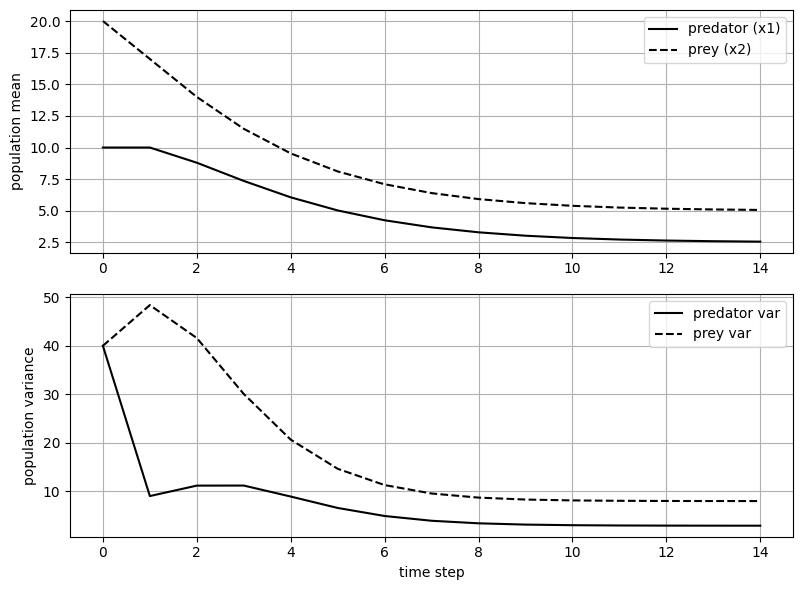

In [23]:
# =========================================
# 1️⃣ 라이브러리 불러오기
# =========================================
import numpy as np
import matplotlib.pyplot as plt


# =========================================
# 2️⃣ 시스템 모델 정의
#    x_{k+1} = F @ x_k + G * u_k + w_k
#    w_k ~ N(0, Q)
# =========================================
F = np.array([[0.2, 0.4],
              [-0.4, 1.0]])              # (2,2) 상태 전이 행렬

G = np.array([[0.0],
              [1.0]])                    # (2,1) 입력 행렬 (열벡터로 명시)

Q = np.diag([1.0, 2.0])                  # (2,2) process noise 공분산
                                         # diag(1,2) → 대각만 1,2이고 나머지 0

u = 1.0                                  # 제어 입력 (스칼라)


# =========================================
# 3️⃣ 초기 조건 설정
#    x_bar_0 = [10, 20]^T  (초기 평균)
#    P_0 = diag(40, 40)    (초기 공분산)
# =========================================
x_bar = np.array([[10.0],                # (2,1) 열벡터로 명시
                  [20.0]])               # → F @ x_bar 의 차원이 (2,1)로 깔끔

P = np.diag([40.0, 40.0])                # (2,2)

N = 15                                   # 0 ~ 14 step (총 15개)


# =========================================
# 4️⃣ 저장 배열 준비
#    - 각 시간의 평균과 분산(대각만)을 저장
#    - 그림에서 보여줄 건 mean 2개, variance 2개
# =========================================
mean_history = np.zeros((N, 2))          # 각 step의 [prey_mean, predator_mean]
                                         # 주의: 책에서 x(1)=predator, x(2)=prey

var_history  = np.zeros((N, 2))          # 각 step의 [P[0,0], P[1,1]]


# 초기값 저장 (k=0)
mean_history[0] = x_bar.flatten()        # (2,1) → (2,) 로 펴서 저장
var_history[0]  = np.diag(P)             # 대각 원소만 추출 → (2,)  # 이게 np.diag(P) 이게 원소가 4개래 


# =========================================
# 5️⃣ Propagation 루프
#    매 step:
#      x_bar = F @ x_bar + G * u           ← 평균 전파 (식 4.2)
#      P     = F @ P @ F.T + Q             ← 공분산 전파 (식 4.4)
# =========================================
for k in range(1, N): # 0부터 14까지 인데 이미 0은 초기화 해둠 
    # 평균 전파
    x_bar = F @ x_bar + G * u            # (2,1) = (2,2)@(2,1) + (2,1)*scalar

    # 공분산 전파
    P = F @ P @ F.T + Q                  # (2,2) = (2,2)@(2,2)@(2,2) + (2,2)
                                         # F.T 는 F의 전치 (transpose)

    # 저장
    mean_history[k] = x_bar.flatten()
    var_history[k]  = np.diag(P)         # np.diag(행렬) → 대각 원소를 1D로 반환


# =========================================
# 6️⃣ Steady-state 이론값 계산 (검증용)
#    x_ss = (I - F)^(-1) @ G @ u
#    P_ss : 책 (4.11) 참고 → 시뮬레이션 마지막 값과 비교
# =========================================
I = np.eye(2)                            # 2x2 단위행렬
x_ss = np.linalg.solve(I - F, G * u)     # (I-F) x_ss = G*u 를 풀이
                                         # inv(I-F) @ G*u 보다 안정적

print("Steady-state mean (이론):", x_ss.flatten(),"\n")
print("Steady-state mean (수치)", mean_history[-1],"\n")
# from scipy.linalg import solve_discrete_lyapunov
# P_ss = solve_discrete_lyapunov(F, Q)
P_ss_book = np.array([[2.88, 3.08],
                      [3.08, 7.96]])
print("Steady-state P (이론):\n", P_ss_book,"\n")  
print("Steady-state P (수치):\n", P,"\n")

print("x_ss",x_ss)

# =========================================
# 7️⃣ 결과 시각화 (Figure 4.1 재현)
#    위:  population mean
#    아래: population variance
# =========================================
time_steps = np.arange(N)                # [0, 1, 2, ..., 14]

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# --- 평균 ---
axes[0].plot(time_steps, mean_history[:, 0], 'k-',  label='predator (x1)') # mean이 nx2 메트릭스임 
axes[0].plot(time_steps, mean_history[:, 1], 'k--', label='prey (x2)')
axes[0].set_ylabel('population mean')
axes[0].legend()
axes[0].grid()

# --- 분산 ---
axes[1].plot(time_steps, var_history[:, 0], 'k-',  label='predator var')
axes[1].plot(time_steps, var_history[:, 1], 'k--', label='prey var')
axes[1].set_xlabel('time step')
axes[1].set_ylabel('population variance')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()